# 05 — Real-Time Browser Camera Detection

This notebook implements the real-time inference stage of the Electronic Waste Detection and Classification system.

The trained YOLO26n model (`best.pt`) is loaded from Google Drive and used to process frames obtained from the browser camera.

For each frame, the system performs:

1. Object detection
2. Object localization using bounding boxes
3. Object classification
4. Confidence-score estimation
5. Real-time visualization of detected objects

No model training is performed in this notebook.

## Step 37 — Environment and Model Setup

The real-time inference environment is prepared by installing the required Ultralytics package, mounting Google Drive, and locating the trained YOLO26n model.

In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.8 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
from pathlib import Path

BEST_MODEL = Path(
    "/content/drive/MyDrive/CV_Project/yolo26n_training/weights/best.pt"
)

print("=" * 75)
print("REAL-TIME DETECTION SETUP")
print("=" * 75)

print(f"\nModel path: {BEST_MODEL}")
print(f"Model exists: {BEST_MODEL.exists()}")

if not BEST_MODEL.exists():
    raise FileNotFoundError(
        "best.pt was not found at the expected Google Drive location."
    )

print("\n✓ Trained YOLO26n model is available")

REAL-TIME DETECTION SETUP

Model path: /content/drive/MyDrive/CV_Project/yolo26n_training/weights/best.pt
Model exists: True

✓ Trained YOLO26n model is available


## Step 38 — Load the Trained YOLO26n Model

The best-performing trained checkpoint (`best.pt`) is loaded for inference.

The model retains the 37-class e-waste classification configuration learned during training.

In [7]:
from ultralytics import YOLO

model = YOLO(str(BEST_MODEL))

print("=" * 75)
print("MODEL LOADED")
print("=" * 75)

print(f"\nModel: YOLO26n")
print(f"Number of classes: {len(model.names)}")

print("\nClass mapping:")
for class_id, class_name in model.names.items():
    print(f"{class_id:2d}: {class_name}")

print("\n✓ Model loaded successfully")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
MODEL LOADED

Model: YOLO26n
Number of classes: 37

Class mapping:
 0: Battery
 1: Blood-Pressure-Monitor
 2: Boiler
 3: Clothes-Iron
 4: Coffee-Machine
 5: Computer-Keyboard
 6: Computer-Mouse
 7: Cooling-Display
 8: Desktop-PC
 9: Digital-Oscilloscope
10: Drone
11: Electric-Guitar
12: Electronic-Keyboard
13: Flashlight
14: Flat-Panel-Monitor
15: Flat-Panel-TV
16: Glucose-Meter
17: HDD
18: Laptop
19: Microwave
20: Music-Player
21: Oven
22: PCB
23: Photovoltaic-Panel
24: Projector
25: Refrigerator
26: Rotary-Mower
27: Router
28: Server
29: Smartphone
30: Smoke-Detector
31: Straight-Tube-Fluorescent-Lamp
32: Street-Lamp
33: TV-Remote-Control
34: Telephone-Set
35: USB-Flash-Drive
36: Washing-Machine


## Step 39 — Browser Camera Access

The browser camera is accessed through JavaScript using the browser's camera API.

A live frame is captured from the camera and transferred to the Python runtime for YOLO26n inference.

The camera itself is only the image source. Object detection and classification are performed by the trained YOLO26n model.

In [24]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image

In [25]:
def take_photo(quality=0.8):
    js = Javascript("""
    async function takePhoto(quality) {
        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.display = 'block';
        video.style.width = '640px';

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(
            document.documentElement.scrollHeight,
            true
        );

        await new Promise((resolve) => {
            video.onloadedmetadata = resolve;
        });

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    binary = b64decode(data.split(',')[1])

    image = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        image,
        cv2.IMREAD_COLOR
    )

    return frame

## Step 40 — Single Browser-Camera Frame Test

Before implementing continuous real-time detection, one camera frame is captured and passed through the trained YOLO26n model.

This staged approach verifies camera access and inference independently before combining them into a continuous real-time pipeline.

## Step 42 — Browser Camera Capture

A browser-based camera interface is created to capture an image frame from the user's webcam.

The captured frame will then be passed to the trained YOLO26n model for object detection and classification.

In [26]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image


def capture_camera_frame():
    js = Javascript("""
    async function captureCameraFrame() {

        const container = document.createElement('div');

        const video = document.createElement('video');
        video.style.width = '640px';
        video.style.display = 'block';

        const button = document.createElement('button');
        button.textContent = 'Capture Image';
        button.style.fontSize = '18px';
        button.style.padding = '10px 20px';
        button.style.marginTop = '10px';

        container.appendChild(video);
        container.appendChild(button);
        document.body.appendChild(container);

        const stream =
            await navigator.mediaDevices.getUserMedia({
                video: true
            });

        video.srcObject = stream;

        await video.play();

        await new Promise((resolve) => {
            button.onclick = resolve;
        });

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

        stream.getVideoTracks()[0].stop();

        container.remove();

        return canvas.toDataURL(
            'image/jpeg',
            0.9
        );
    }

    captureCameraFrame();
    """)

    display(js)

    data = eval_js("captureCameraFrame()")

    binary = b64decode(
        data.split(',')[1]
    )

    image = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        image,
        cv2.IMREAD_COLOR
    )

    return frame

BROWSER CAMERA CAPTURE

Camera will open below.
1. Show your smartphone clearly.
2. Click 'Capture Image'.
3. The captured frame will be returned to Python.


<IPython.core.display.Javascript object>


✓ Frame captured successfully
Frame shape: (480, 640, 3)


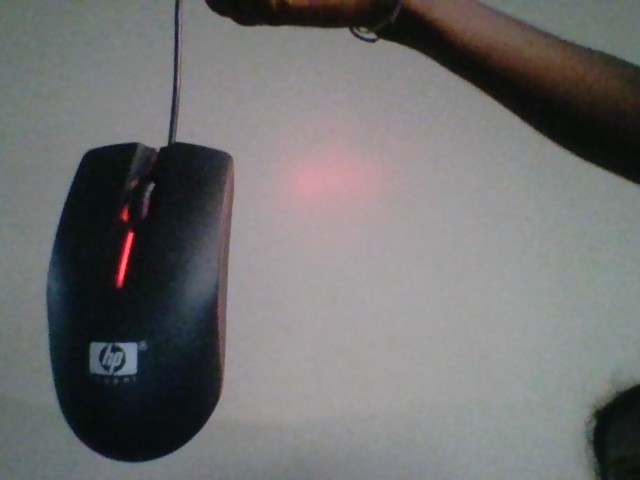

In [27]:
print("=" * 75)
print("BROWSER CAMERA CAPTURE")
print("=" * 75)

print("\nCamera will open below.")
print("1. Show your smartphone clearly.")
print("2. Click 'Capture Image'.")
print("3. The captured frame will be returned to Python.")

frame = capture_camera_frame()

print("\n✓ Frame captured successfully")
print("Frame shape:", frame.shape)

display(
    Image.fromarray(
        cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )
    )
)

## Step 42 — Inspect Captured Browser-Camera Frame

Before continuing with real-time inference, the captured camera frame is inspected to verify that the browser camera image was correctly transferred to the Python runtime.

CAPTURED CAMERA FRAME CHECK

Frame type: <class 'numpy.ndarray'>
Frame shape: (480, 640, 3)
Frame dtype: uint8


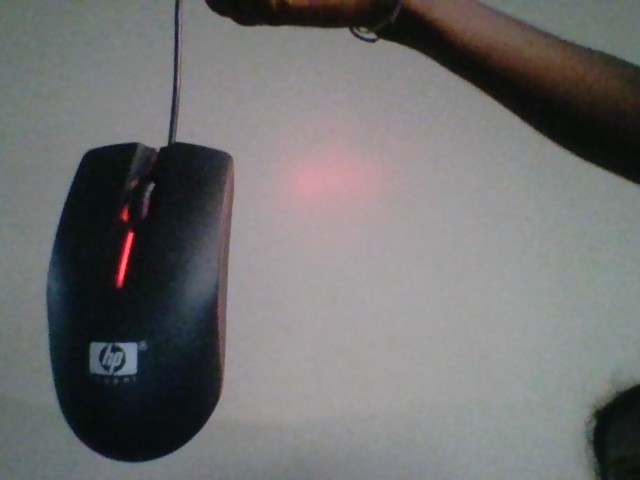

In [28]:
print("=" * 75)
print("CAPTURED CAMERA FRAME CHECK")
print("=" * 75)

print("\nFrame type:", type(frame))
print("Frame shape:", frame.shape)
print("Frame dtype:", frame.dtype)

display(
    Image.fromarray(
        cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    )
)

## Step 43 — Diagnostic YOLO26n Inference

The captured browser-camera frame is passed to the trained YOLO26n model using a lower confidence threshold for diagnostic purposes.

This test is intended to determine whether the model produces any candidate detections for the captured frame.

DIAGNOSTIC YOLO26n INFERENCE

0: 480x640 1 Computer-Mouse, 11.7ms
Speed: 1.7ms preprocess, 11.7ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

Number of detections: 1

Detections:
Computer-Mouse                      Confidence: 0.952


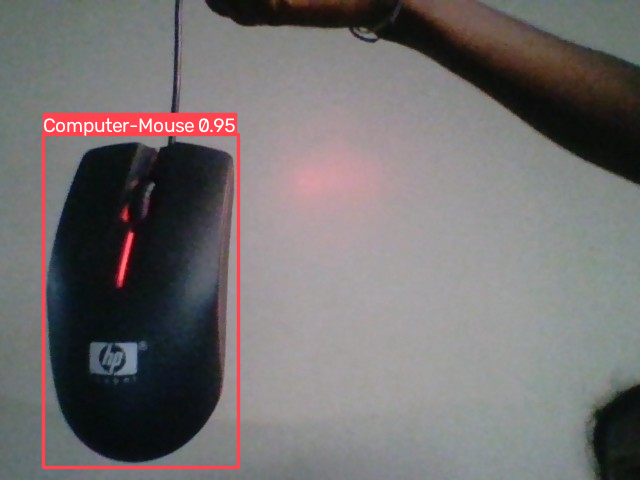

In [29]:
print("=" * 75)
print("DIAGNOSTIC YOLO26n INFERENCE")
print("=" * 75)

results = model.predict(
    source=frame,
    imgsz=640,
    conf=0.10,
    verbose=True
)

result = results[0]

print("\nNumber of detections:",
      0 if result.boxes is None else len(result.boxes))

if result.boxes is not None and len(result.boxes) > 0:

    print("\nDetections:")

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]

        print(
            f"{class_name:<35} "
            f"Confidence: {confidence:.3f}"
        )

else:
    print("\nNo detections produced.")

annotated = result.plot()

display(
    Image.fromarray(
        cv2.cvtColor(
            annotated,
            cv2.COLOR_BGR2RGB
        )
    )
)